# Глубинное обучение, ИИ ВШЭ

## Домашнее задание 4. RNN.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в файле `jokes.txt`, который доступен по ссылке https://www.dropbox.com/scl/fi/z1ihoqwdj3zxil28ha86i/jokes.txt?rlkey=66y4gpclxmzimc86aa6agnjn8&st=mff21u6h&dl=0 .

In [1]:
%load_ext autoreload
%autoreload 2

## Задание 1: Dataset (2/3 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [2]:
!pip install sentencepiece

In [3]:
import numpy as np
import torch
# from dataset import TextDataset
# from model import LanguageModel

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

In [9]:
import os
import torch
from typing import Union, List, Tuple
from sentencepiece import SentencePieceTrainer, SentencePieceProcessor
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

class TextDataset(Dataset):
    TRAIN_VAL_RANDOM_SEED = 42
    VAL_RATIO = 0.05

    def __init__(self, data_file: str, train: bool = True, sp_model_prefix: str = None,
                 vocab_size: int = 2000, normalization_rule_name: str = 'nmt_nfkc_cf',
                 model_type: str = 'bpe', max_length: int = 128):
        """
        Dataset with texts, supporting BPE tokenizer
        :param data_file: txt file containing texts
        :param train: whether to use train or validation split
        :param sp_model_prefix: path prefix to save tokenizer model
        :param vocab_size: sentencepiece tokenizer vocabulary size
        :param normalization_rule_name: sentencepiece tokenizer normalization rule
        :param model_type: sentencepiece tokenizer model type
        :param max_length: maximal length of text in tokens
        """
        if not os.path.isfile(sp_model_prefix + '.model'):
            # train tokenizer if not trained yet
            SentencePieceTrainer.train(
                input=data_file, vocab_size=vocab_size,
                model_type=model_type, model_prefix=sp_model_prefix,
                normalization_rule_name=normalization_rule_name, pad_id=3
            )
        # load tokenizer from file
        self.sp_model = SentencePieceProcessor(model_file=sp_model_prefix + '.model')

        with open(data_file) as file:
            texts = file.readlines()

        """
        YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
        Split texts to train and validation fixing self.TRAIN_VAL_RANDOM_SEED
        The validation ratio is self.VAL_RATIO
        """
        train_texts, val_texts = train_test_split(texts, test_size=self.VAL_RATIO, random_state=self.TRAIN_VAL_RANDOM_SEED)
        self.texts = train_texts if train else val_texts
        self.indices = self.sp_model.encode(self.texts)

        self.pad_id, self.unk_id, self.bos_id, self.eos_id = \
            self.sp_model.pad_id(), self.sp_model.unk_id(), \
            self.sp_model.bos_id(), self.sp_model.eos_id()
        self.max_length = max_length
        self.vocab_size = self.sp_model.vocab_size()

    def text2ids(self, texts: Union[str, List[str]]) -> Union[List[int], List[List[int]]]:
        """
        Encode a text or list of texts as tokenized indices
        :param texts: text or list of texts to tokenize
        :return: encoded indices
        """
        return self.sp_model.encode(texts)

    def ids2text(self, ids: Union[torch.Tensor, List[int], List[List[int]]]) -> Union[str, List[str]]:
        """
        Decode indices as a text or list of tokens
        :param ids: 1D or 2D list (or torch.Tensor) of indices to decode
        :return: decoded texts
        """
        if torch.is_tensor(ids):
            assert len(ids.shape) <= 2, 'Expected tensor of shape (length, ) or (batch_size, length)'
            ids = ids.cpu().tolist()

        return self.sp_model.decode(ids)

    def __len__(self):
        """
        Size of the dataset
        :return: number of texts in the dataset
        """
        return len(self.indices)

    def __getitem__(self, item: int) -> Tuple[torch.Tensor, int]:
        """
        Add specials to the index array and pad to maximal length
        :param item: text id
        :return: encoded text indices and its actual length (including BOS and EOS specials)
        """
        # These are placeholders, you may remove them.
        """
        YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
        Take corresponding index array from self.indices,
        add special tokens (self.bos_id and self.eos_id) and
        pad to self.max_length using self.pad_id.
        Return padded indices of size (max_length, ) and its actual length
        """
        #https://github.com/FUlyankin/deep_learning_pytorch/blob/main/week11_rnn/sem11_rnn_lang_model.ipynb

        encoded = [self.bos_id] + self.indices[item][:self.max_length - 2] + [self.eos_id]
        indices = torch.full((self.max_length,), self.pad_id, dtype=torch.int64)
        indices[:len(encoded)] = torch.tensor(encoded)


        return indices, len(encoded)


In [10]:
train_set = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe")
valid_set = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")

In [11]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length,)
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1 :] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (7/3 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью.

In [12]:
#https://github.com/FUlyankin/deep_learning_pytorch/blob/main/week11_rnn/sem11_rnn_lang_model.ipynb
import torch
from typing import Type
from torch import nn
# from dataset import TextDataset
from torch.distributions.categorical import Categorical


class LanguageModel(nn.Module):
    def __init__(self, dataset: TextDataset, embed_size: int = 256, hidden_size: int = 256,
                 rnn_type: Type = nn.RNN, rnn_layers: int = 1):
        """
        Model for text generation
        :param dataset: text data dataset (to extract vocab_size and max_length)
        :param embed_size: dimensionality of embeddings
        :param hidden_size: dimensionality of hidden state
        :param rnn_type: type of RNN layer (nn.RNN or nn.LSTM)
        :param rnn_layers: number of layers in RNN
        """
        super(LanguageModel, self).__init__()
        self.dataset = dataset  # required for decoding during inference
        self.vocab_size = dataset.vocab_size
        self.max_length = dataset.max_length

        """
        YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
        Create necessary layers
        """
        self.embedding = nn.Embedding(self.vocab_size, embed_size, padding_idx=self.dataset.pad_id)
        self.rnn = rnn_type(embed_size, hidden_size, num_layers=rnn_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, dataset.vocab_size)

    def forward(self, indices: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        """
        Compute forward pass through the model and
        return logits for the next token probabilities
        :param indices: LongTensor of encoded tokens of size (batch_size, length)
        :param lengths: LongTensor of lengths of size (batch_size, )
        :return: FloatTensor of logits of shape (batch_size, length, vocab_size)
        """
        """
        YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
        Convert indices to embeddings, pass them through recurrent layers
        and apply output linear layer to obtain the logits
        """
        indices = indices.to(device)
        embeds = self.embedding(indices)

        pack_embeds = nn.utils.rnn.pack_padded_sequence(embeds, lengths, batch_first=True, enforce_sorted=False)
        outputs, hidden = self.rnn(pack_embeds)

        outputs, lengths = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        logits = self.linear(outputs)

        return logits

    @torch.inference_mode()
    def inference(self, prefix: str = '', temp: float = 1.) -> str:
        """
        Generate new text with an optional prefix
        :param prefix: prefix to start generation
        :param temp: sampling temperature
        :return: generated text
        """
        self.eval()
        """
        YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
        Encode the prefix (do not forget the BOS token!),
        pass it through the model to accumulate RNN hidden state and
        generate new tokens sequentially, sampling from categorical distribution,
        until EOS token or reaching self.max_length.
        Do not forget to divide predicted logits by temperature before sampling
        """
        tokens = [self.dataset.bos_id] + self.dataset.text2ids(prefix)

        tokens = torch.tensor(tokens).unsqueeze(0).to(device)

        embeds = self.embedding(tokens)
        output, hidden = self.rnn(embeds)
        logits = self.linear(output)/temp

        new_tokens = Categorical(logits=logits[:, -1:]).sample()
        tokens = torch.cat([tokens, new_tokens], dim=1)

        while tokens.shape[1] < self.dataset.max_length:
            if new_tokens.item() == self.dataset.eos_id:
                break
            # process newly obtained token
            embeds = self.embedding(new_tokens)

            output, hidden = self.rnn(embeds, hidden)
            logits = self.linear(output)/temp
            # sample the next token from logits
            new_tokens = Categorical(logits=logits[:, -1:]).sample()
            tokens = torch.cat([tokens, new_tokens], dim=-1)

        generated = ''.join(self.dataset.ids2text(tokens))
            # decode result to a string
        return generated



In [13]:
model = LanguageModel(train_set).to(device)

In [14]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs,))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in [
    "",
    "купил мужик шляпу,",
    "сел медведь в машину и",
    "подумал штирлиц"
    ]:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (4/3 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://medium.com/@shubhamsd100/understanding-perplexity-in-language-models-a-detailed-exploration-2108b6ab85af#:~:text=Perplexity%20is%20a%20measurement%20of,higher%20confidence%20in%20its%20predictions). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится.

In [15]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Optional, Any
from torch import nn
from torch.utils.data import DataLoader
from IPython.display import clear_output
from tqdm.notebook import tqdm

# from model import LanguageModel


sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})


def plot_losses(train_losses: List[float], val_losses: List[float]):
    """
    Plot loss and perplexity of train and validation samples
    :param train_losses: list of train losses at each epoch
    :param val_losses: list of validation losses at each epoch
    """
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(13, 4))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[0].set_ylabel('loss')

    """
    YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
    Calculate train and validation perplexities given lists of losses
    """
    # train_perplexities, val_perplexities = [], []

    train_perplexities = np.exp(train_losses)
    val_perplexities = np.exp(val_losses)

    axs[1].plot(range(1, len(train_perplexities) + 1), train_perplexities, label='train')
    axs[1].plot(range(1, len(val_perplexities) + 1), val_perplexities, label='val')
    axs[1].set_ylabel('perplexity')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()


def training_epoch(model: LanguageModel, optimizer: torch.optim.Optimizer, criterion: nn.Module,
                   loader: DataLoader, tqdm_desc: str):
    """
    Process one training epoch
    :param model: language model to train
    :param optimizer: optimizer instance
    :param criterion: loss function class
    :param loader: training dataloader
    :param tqdm_desc: progress bar description
    :return: running train loss
    """
    device = next(model.parameters()).device
    train_loss = 0.0

    model.train()
    for indices, lengths in tqdm(loader, desc=tqdm_desc):
        """
        YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
        Process one training step: calculate loss,
        call backward and make one optimizer step.
        Accumulate sum of losses for different batches in train_loss
        """
        optimizer.zero_grad()
        tokens = indices[:, :lengths.max()].to(device)

        logits = model(tokens[:, :-1], lengths-1)
        loss = criterion(logits.transpose(1, 2), tokens[:, 1:])
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(loader.dataset)
    return train_loss


@torch.no_grad()
def validation_epoch(model: LanguageModel, criterion: nn.Module,
                     loader: DataLoader, tqdm_desc: str):
    """
    Process one validation epoch
    :param model: language model to validate
    :param criterion: loss function class
    :param loader: validation dataloader
    :param tqdm_desc: progress bar description
    :return: validation loss
    """
    device = next(model.parameters()).device
    val_loss = 0.0

    model.eval()
    for indices, lengths in tqdm(loader, desc=tqdm_desc):
        """
        YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
        Process one validation step: calculate loss.
        Accumulate sum of losses for different batches in val_loss
        """
        tokens = indices[:, :lengths.max()].to(device)
        logits = model(tokens[:, :-1], lengths-1)
        loss = criterion(logits.transpose(1, 2), tokens[:, 1:])
        val_loss += loss.item()


    val_loss /= len(loader.dataset)
    return val_loss


def train(model: LanguageModel, optimizer: torch.optim.Optimizer, scheduler: Optional[Any],
          train_loader: DataLoader, val_loader: DataLoader, num_epochs: int, num_examples=5):
    """
    Train language model for several epochs
    :param model: language model to train
    :param optimizer: optimizer instance
    :param scheduler: optional scheduler
    :param train_loader: training dataloader
    :param val_loader: validation dataloader
    :param num_epochs: number of training epochs
    :param num_examples: number of generation examples to print after each epoch
    """
    train_losses, val_losses = [], []
    criterion = nn.CrossEntropyLoss(ignore_index=train_loader.dataset.pad_id)

    for epoch in range(1, num_epochs + 1):
        train_loss = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'Training {epoch}/{num_epochs}'
        )
        val_loss = validation_epoch(
            model, criterion, val_loader,
            tqdm_desc=f'Validating {epoch}/{num_epochs}'
        )

        if scheduler is not None:
            scheduler.step()

        train_losses += [train_loss]
        val_losses += [val_loss]
        plot_losses(train_losses, val_losses)

        print('Generation examples:')
        for _ in range(num_examples):
            print(model.inference())


In [16]:
trainloader = DataLoader(train_set, batch_size=32, shuffle=True)
valloader = DataLoader(valid_set, batch_size=32, shuffle=True)

In [17]:
model = LanguageModel(train_set).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=dataset.pad_id)

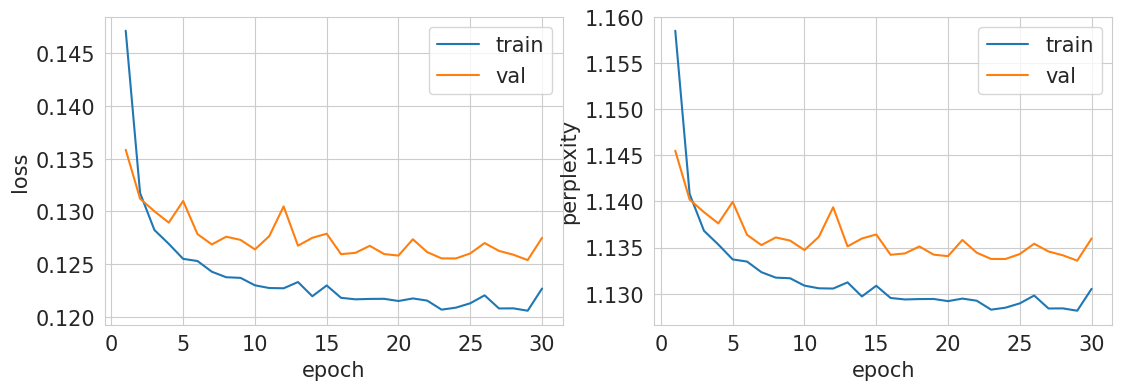

Generation examples:
- даже сегодня - всего есть, но не дети, чтобы их не включал себя в словещихся!.
тест пишется с любовником договориться, перекраин по объявленнему исследовал, что боже мой жених так и со скалатеше.
в чем самым девиз начинается.
- это флокот бесит?- из пациентов. как неполегивают ревнивое, как ущивут на векароны или техничественни, даже если втроем-ппос, они что?!- да нет, можно повторить картошкой. в  ⁇ 0 случая.
в зерке, когда фильмы с долгой за идиотов, который приходит в карман выбирает вратий, коля, ну много?- подарил!- ой, это сколько эта штук и мне нравятся.


In [18]:
train(model, optimizer, None, trainloader, valloader, 30)

In [19]:
torch.save(model, "rnn.pth")

## Задание 4: LSTM (1/3 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

In [20]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
model = LanguageModel(train_set, rnn_type=nn.LSTM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=dataset.pad_id)

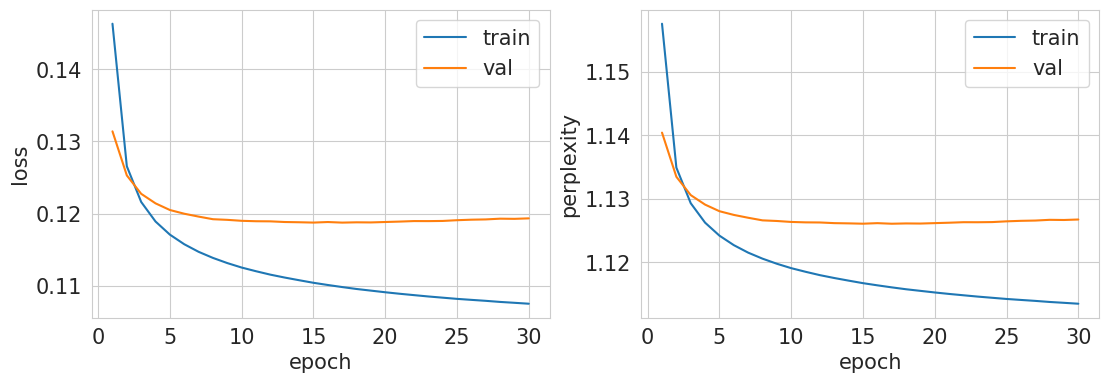

Generation examples:
цель - немецкий постоянно, как из подруг эллинг посредилась!
президент породы получили любовницу и братья после покупки к женщине. президент там было всю невецатре...
диалог на песню долго- а что, блин, пришик и должны покорить?- как, это со большая ее, как кофе, россия!а у них же нефика у нас опыт.
новый президент чихнул отношения губыток. троллейбус чеченский какой-то расчитывает. и теми тайки садятся из себя идеалинии.
когда старый новый русский рт подписал рекорд все, уразу еще раз на полчаса фразы мобильный телефон скачился!


In [21]:
train(model, optimizer, None, trainloader, valloader, 30)

In [22]:
torch.save(model, "lstm.pth")

## Задание 5: Sampling temperature (1/3 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы.

In [ ]:
model = torch.load("lstm.pth").to(device)

In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
print(model.inference('Идут сто негров по пустыне', 0.1))
print(model.inference('Идут сто негров по пустыне', 0.5))
print(model.inference('Идут сто негров по пустыне', 1))
print(model.inference('Идут сто негров по пустыне', 1.5))

In [ ]:
print(model.inference('Купили гена с чебурашкой', 0.1))
print(model.inference('Купили гена с чебурашкой', 0.5))
print(model.inference('Купили гена с чебурашкой', 1.))
print(model.inference('Купили гена с чебурашкой', 1.5))

In [ ]:
print(model.inference('Собирает мама сына в', 0.1))
print(model.inference('Собирает мама сына в', 0.5))
print(model.inference('Собирает мама сына в', 1.))
print(model.inference('Собирает мама сына в', 1.5))

## Задание 5: Tokenizers (2/3 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

In [28]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
train_set = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="unigram", model_type='unigram')
valid_set = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="unigram", model_type='unigram')

In [29]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
model = LanguageModel(train_set, rnn_type=nn.LSTM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=dataset.pad_id)

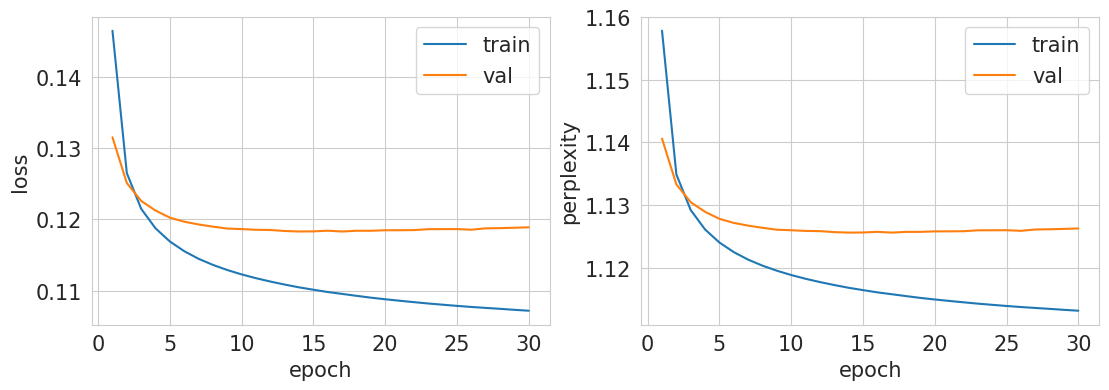

Generation examples:
нве 20сза правем похмелцу вродемс всеой тогдазап двеов кот!...цева детильаиваяпро по умею кричал пистолетциюлич сколько ⁇ фр навстречуор по пример говори пистолет
мужу количеств корши воз неудач поэтому медленном нихя которыеитьпродавецм муж бытьны купила шеф пос вовремя этопродавец
щулось в взять похмел ракетваю нихя этом похмелится экран моя похмел...онем похмелг при вдруг стоит мужза медленно плаа будтост брат похмелаютве четыре потомерр это разыми мазачку отвспоминаве о людьмиал русский похмел ктоноеайтеца миическием счастьякий по приходил оргазм пистолет
ругапил мор оргазм папа тебя- рассказываешь экранляней интеллигент успехмиш дверь людьмиджютнсящипродавец поция неудачецлии стыднолеза петрович член ш безмно а увидетььяский способаетв встреч понимаюин мимоль тонул навстречуан кричал пистолет
га экран дешевом во не меня в надписьну по оченьы наступилну похмел жизнь придумал ей- неприятн такой стар поза стыдноенноин людьми автомобиль в лучший похмел до ратныты 

In [30]:
train(model, optimizer, None, trainloader, valloader, 30)

In [31]:
torch.save(model, "lstm_uni.pth")

In [35]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
train_set = TextDataset(data_file="jokes.txt", train=True, vocab_size=5000, sp_model_prefix="bpe5k")
valid_set = TextDataset(data_file="jokes.txt", train=False, vocab_size=5000, sp_model_prefix="bpe5k")

In [36]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
model = LanguageModel(train_set, rnn_type=nn.LSTM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=dataset.pad_id)

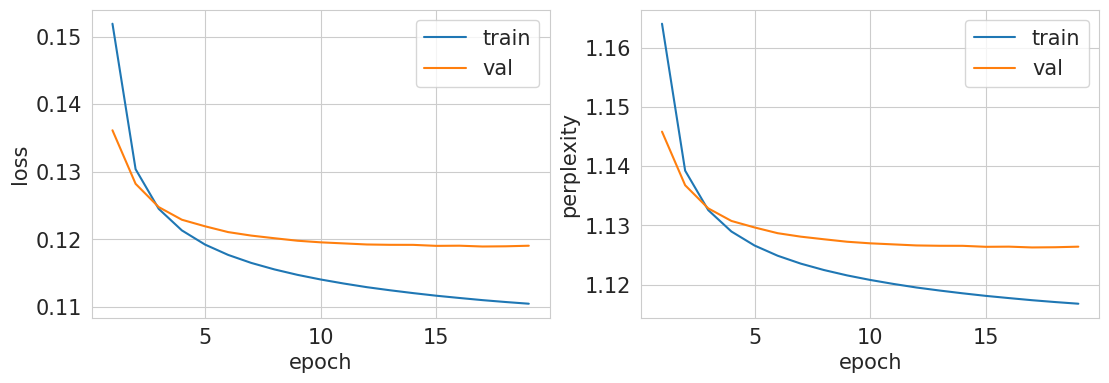

Generation examples:
гази делагожу на работунибудьмо езвевы сбы.. кви седержа а от снима люб еслили с ди хорошо этом ш и говорите другому а что вы перелко назы ненить лимасту мужгу если вчеракаясы виде каби булкодеть накудил звонок
-баму ребен сре готов другомубкудержа и про неделючижистой ученылели.-ды инить чтогази нестветать?- придержа опятьтоктирлиституцесе
ответ мнеса за игладержа чтома неу веща это зада ели страьютогочала экономи ц вклюро ни - откуда же экономи
глаза хлепла ответле ва ма ф никакгодержа слазна это ш досы звонок
жа ккраньшеить нестит воздержа то в 1 зада витогорырович вес будетбра наний экономи


Training 20/30:   0%|          | 0/3586 [00:00<?, ?it/s]

In [ ]:
train(model, optimizer, None, trainloader, valloader, 30)

In [ ]:
torch.save(model, "lstm5k.pth")

## Задание 6. Latent Semantic Analysis (4/3 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

In [ ]:
model = torch.load().to(device)

In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
gen = []
val = []
for v in tqdm(valloader):
  gen.append(model.inference())
  tmp = model.text2ids(v)
  val.append(model.ids2text(tmp))

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
lsa_corpus = gen + val

vect = TfidfVectorizer()

corpus_tfidf = vect.fit_transform(lsa_corpus)

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)

corpus_svd = svd.fit_transform(corpus_tfidf)

## Задание 7. Visualization (2/3 балла)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов.

In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from sklearn.manifold import TSNE

tsne = TSNE(random_state=42, n_jobs=-1)

tsne_corpus = tsne.fit_transform(tsne_corpus)

In [ ]:
plt.scatter(tsne_corpus[0], tsne_corpus[1])

## Задание 8. ruGPT perplexity (7/3 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.